## Aquire dataset in Google Colab

In [1]:
from pathlib import Path

GOOGLE_DRIVE_PATH = Path('/content/drive')
GOOGLE_DRIVE_DATASET_PATH = GOOGLE_DRIVE_PATH / 'MyDrive/cv-cource/Confirmed_fronts.zip'
GOOGLE_DRIVE_DATASET_PATH.exists()

True

In [2]:
# from google.colab import drive
# import zipfile

# drive.mount(str(GOOGLE_DRIVE_PATH.absolute()))
# print("Drive mounted successfully.")

# with zipfile.ZipFile(GOOGLE_DRIVE_DATASET_PATH, 'r') as zip_ref:
#     zip_ref.extractall(Path('.'))

# Лабораторная 1

Задача классификации цвета автомобиля.

Датасет DVM: https://deepvisualmarketing.github.io/, использовать фронтальные виды.

**Ход работы:**
1. Написать своими руками классификатор любой на выбор: ResNet, InceptionV3,
DenseNet, MobileNet, ShuffleNet, и обучить его на датасете для предсказания цвета
автомобиля.
2. Также взять 2 классификатора, но предобученные на ImageNet или другом и дообучить
на предобработанном датасете DVM. Выяснить, чей классификатор лучше.
3. Оценить качество при помощи F1_macro, требуется получить F1_macro > 0.8.
4. Сравнить полученное качество у всех классификаторов между собой и сделать вывод.

## Initialisation

In [26]:
import os
import random

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Using device: cuda
Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


## Data Preparation

In [5]:
BASE_DIR = Path("confirmed_fronts")
assert BASE_DIR.exists(), f"Directory not found: {BASE_DIR.resolve()}"


def collect_samples(base_dir: Path) -> pd.DataFrame:
    """
    Filename format example:
    Brand$$Model$$Year$$Color$$...$$image_x.jpg
    Color is parts[3] after split by '$$'.
    """
    rows = []
    image_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff", ".gif"}

    for path in base_dir.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in image_exts:
            continue

        parts = path.name.split("$$")
        if len(parts) > 4:
            color = parts[3]
            rows.append({"path": str(path), "color": color})

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No images found. Check BASE_DIR path and filename format.")

    return df


df_all = collect_samples(BASE_DIR)
df_all.head()

,path,color
0,confirmed_fronts/Ssangyong/2008/Ssangyong$$Rex...,Black
1,confirmed_fronts/Ssangyong/2008/Ssangyong$$Rex...,Silver
2,confirmed_fronts/Ssangyong/2008/Ssangyong$$Rex...,Magenta
3,confirmed_fronts/Ssangyong/2015/Ssangyong$$Rex...,Blue
4,confirmed_fronts/Ssangyong/2015/Ssangyong$$Tiv...,Black



All Data
Total samples: 61,827


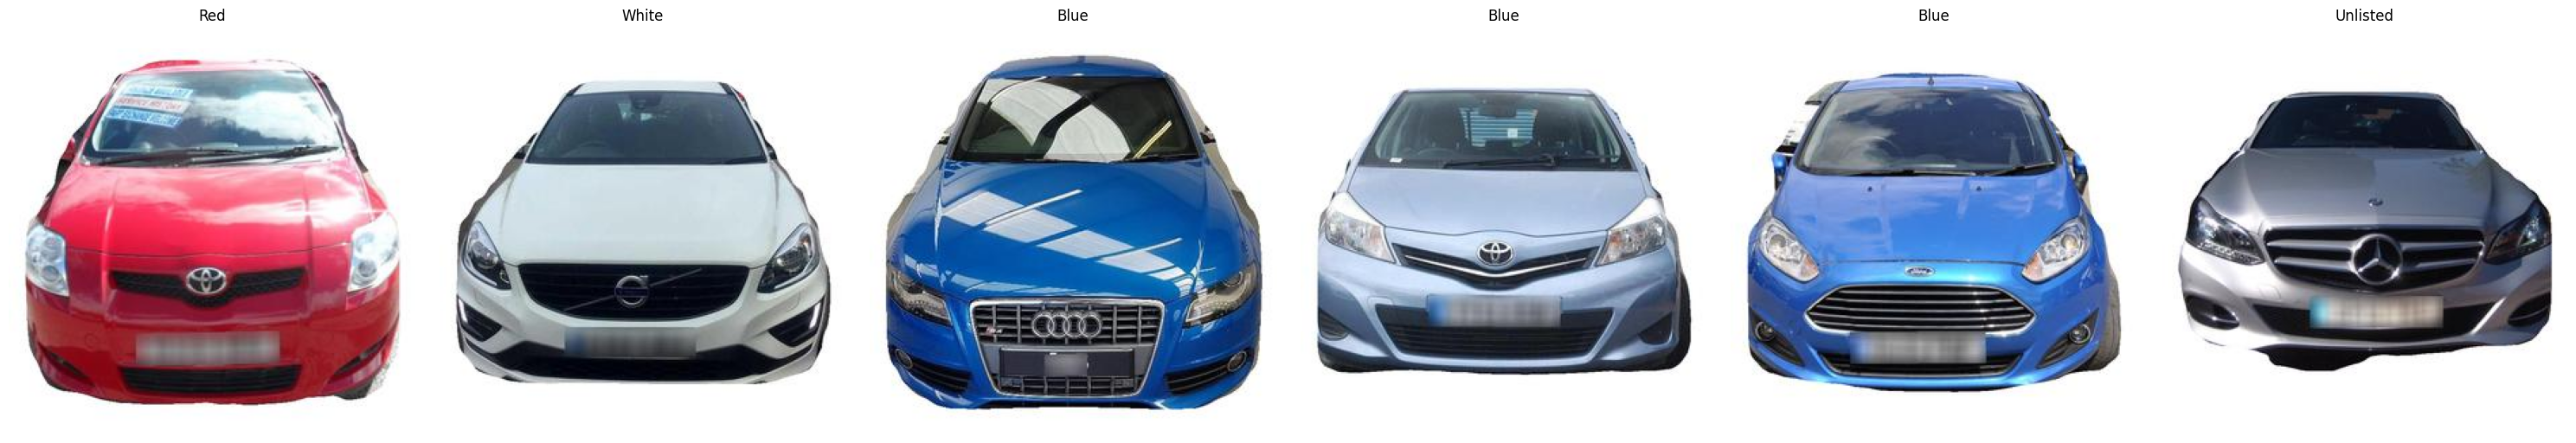

,color,count
0,Black,14317
1,Grey,9474
2,White,9395
3,Blue,8483
4,Silver,7770
5,Red,6095
6,Unlisted,1516
7,Brown,911
8,Green,777
9,Yellow,667


In [6]:
import plotly.express as px
import matplotlib.pyplot as plt


def show_image_grid(images, titles, figsize_per_image=(5, 5), suptitle=None):
    n = len(images)
    _, axes = plt.subplots(1, n, figsize=(figsize_per_image[0] * n, figsize_per_image[1]))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


def describe_dataset(
    dataframe: pd.DataFrame, title: str = "Dataset Description", n_examples: int = 6
):
    print(f"\n{'='*50}")
    print(title)
    print(f"{'='*50}")
    print(f"Total samples: {len(dataframe):,}")

    color_counts = (
        dataframe["color"].value_counts().rename_axis("color").reset_index(name="count")
    )

    fig = px.bar(
        color_counts,
        x="color",
        y="count",
        color="color",
        title=f"{title} - Color Distribution",
        text="count",
    )
    fig.show()

    n_show = min(n_examples, len(dataframe))
    if n_show > 0:
        sample_df = dataframe.sample(n=n_show, random_state=49).reset_index(drop=True)
        images = [Image.open(row["path"]).convert("RGB") for _, row in sample_df.iterrows()]
        titles = list(sample_df["color"])
        show_image_grid(images, titles)

    return color_counts

describe_dataset(df_all, title="All Data")


In [7]:
TARGET_CLASSES = [
    "Black",
    "Grey",
    "White",
    "Blue",
    "Silver",
    "Red",
    "Brown",
    "Green",
    "Yellow",
]

MAX_SAMPLES_PER_CLASS = 5000


def stratified_split_sklearn(
    df: pd.DataFrame,
    label_col: str = "color",
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
    seed: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8, (
        "Ratios must sum to 1.0"
    )

    def _split(
        data: pd.DataFrame, test_size: float
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        left_idx, right_idx = next(sss.split(data, data[label_col]))
        return (
            data.iloc[left_idx].reset_index(drop=True),
            data.iloc[right_idx].reset_index(drop=True),
        )

    train_df, temp_df = _split(df, test_size=1.0 - train_ratio)
    val_df, test_df = _split(temp_df, test_size=test_ratio / (val_ratio + test_ratio))
    return train_df, val_df, test_df


# Оставляем только целевые 9 цветов и выкидываем Unlisted/прочие редкие классы
before_count = len(df_all)
df_all = df_all[df_all["color"].isin(TARGET_CLASSES)].reset_index(drop=True)

# Cap each class at MAX_SAMPLES_PER_CLASS
df_all = pd.concat([
    g.sample(n=min(len(g), MAX_SAMPLES_PER_CLASS), random_state=42)
    for _, g in df_all.groupby("color")
]).reset_index(drop=True)

after_count = len(df_all)

classes = TARGET_CLASSES.copy()
class_to_idx = {name: idx for idx, name in enumerate(classes)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
df_all["label"] = df_all["color"].map(class_to_idx)
train_df, val_df, test_df = stratified_split_sklearn(df_all, label_col="color", seed=42)

describe_dataset(df_all, title="Training Data", n_examples=0)


Training Data
Total samples: 32,355


,color,count
0,Black,5000
1,Blue,5000
2,Grey,5000
3,Silver,5000
4,Red,5000
5,White,5000
6,Brown,911
7,Green,777
8,Yellow,667


In [8]:
train_df, val_df, test_df = stratified_split_sklearn(df_all, label_col="color", seed=42)
print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 22648
Val: 4853
Test: 4854


In [9]:
# ── Quick CPU smoke-test: flip DEBUG=False to use the full dataset ──
DEBUG = False
if DEBUG:
    N_TRAIN, N_VAL, N_TEST = 640, 128, 128
    train_df = train_df.sample(n=N_TRAIN, random_state=42).reset_index(drop=True)
    val_df   = val_df.sample(n=N_VAL,   random_state=42).reset_index(drop=True)
    test_df  = test_df.sample(n=N_TEST,  random_state=42).reset_index(drop=True)
    print(f"[DEBUG] Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


In [10]:
# Аугментации только для Train
train_transforms = transforms.Compose(
    [
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
    ]
)

# Для Val и Test аугментации НЕ делаем, только ресайз и нормализацию
val_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)


class CarColorDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
train_dataset = CarColorDataset(train_df, transform=train_transforms)
val_dataset = CarColorDataset(val_df, transform=val_transforms)
test_dataset = CarColorDataset(test_df, transform=val_transforms)

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ
BATCH_SIZE = 64
NUM_WORKERS = 0 if IN_COLAB else min(4, os.cpu_count() or 1)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    pin_memory=torch.cuda.is_available(),
)
if NUM_WORKERS > 0:
    loader_kwargs.update(
        num_workers=NUM_WORKERS,
        multiprocessing_context="fork",
        persistent_workers=True,
    )

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_kwargs)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 354
Val batches: 76
Test batches: 76


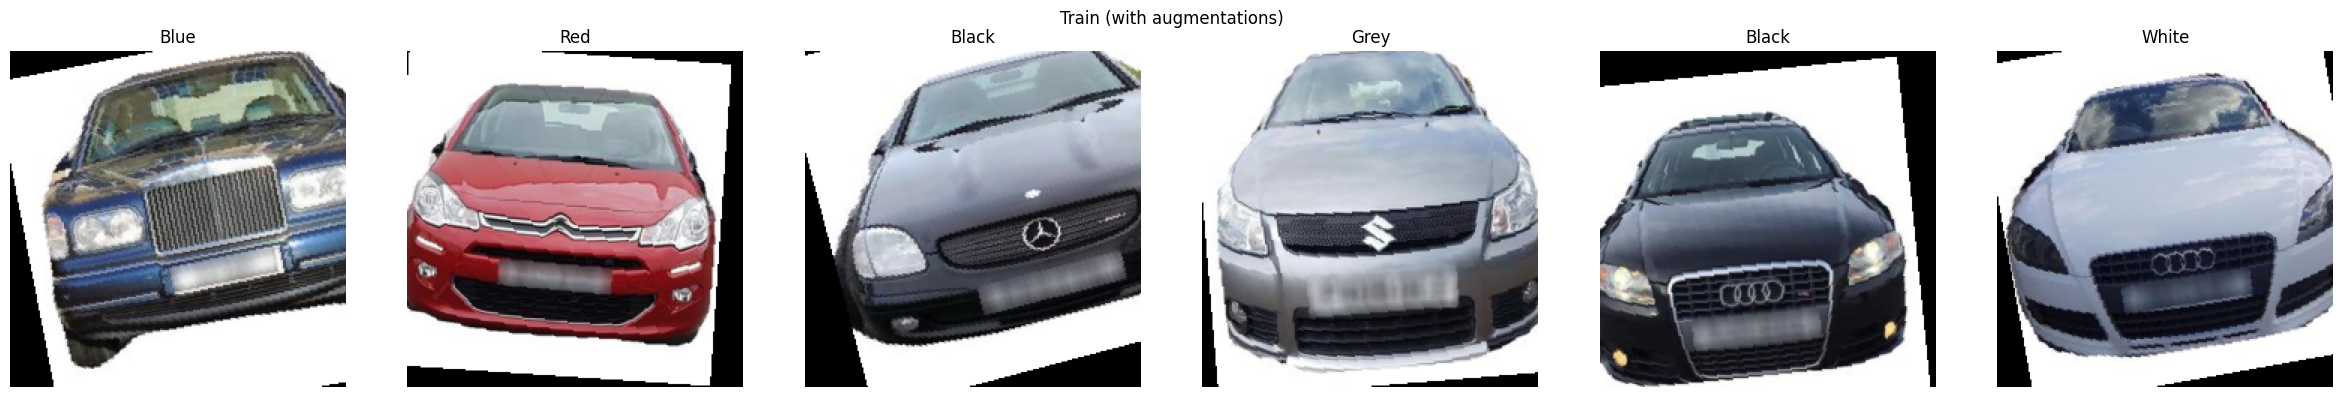

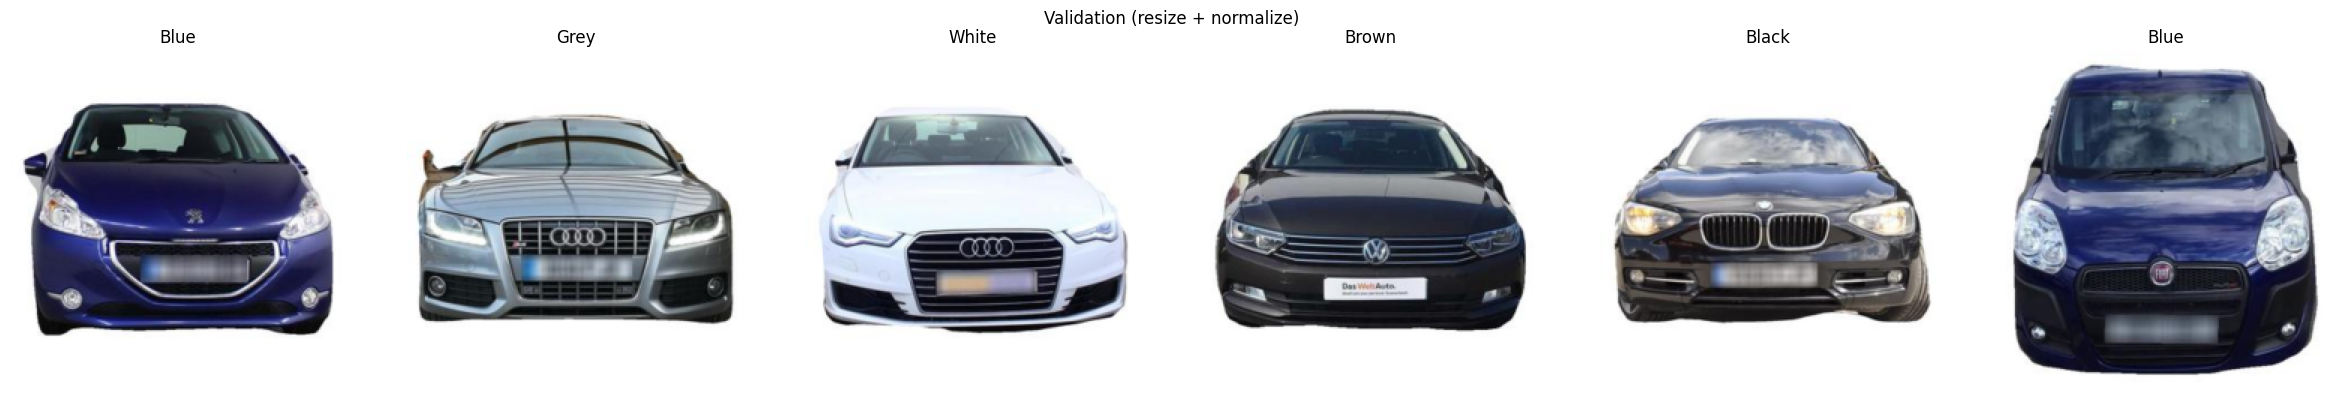

In [12]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor: torch.Tensor) -> torch.Tensor:
    return (img_tensor * std + mean).clamp(0, 1)

def show_transformed_samples(dataset, n=6, title="Samples"):
    n = min(n, len(dataset))
    indices = np.random.choice(len(dataset), size=n, replace=False)
    images, titles = [], []
    for idx in indices:
        img, label = dataset[idx]
        images.append(denormalize(img).permute(1, 2, 0).cpu().numpy())
        titles.append(idx_to_class[label])
    show_image_grid(images, titles, figsize_per_image=(4, 4), suptitle=title)

show_transformed_samples(train_dataset, n=6, title="Train (with augmentations)")
show_transformed_samples(val_dataset, n=6, title="Validation (resize + normalize)")


In [13]:
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss = criterion(logits, labels)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc



def train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    device=DEVICE,
    class_weights: torch.Tensor | None = None,
):
    model = model.to(device)

    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_state = None
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, device=device
        )
        scheduler.step()
        val_loss, val_acc = run_epoch(
            model, val_loader, criterion, optimizer=None, device=device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def evaluate_model(model, test_loader, device=DEVICE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = run_epoch(
        model, test_loader, criterion, optimizer=None, device=device
    )
    print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")
    return {"test_loss": test_loss, "test_acc": test_acc}


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [14]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity
        out = self.relu(out)
        return out


class ResNetCustom(nn.Module):
    def __init__(self, block, layers, num_classes):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = [block(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


def build_custom_resnet18(num_classes):
    return ResNetCustom(BasicBlock, [2, 2, 2, 2], num_classes)

In [15]:
def build_efficientnet_b0_transfer(num_classes, freeze_backbone=False):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    return model


def build_mobilenet_v3_transfer(num_classes, freeze_backbone=False):
    weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
    model = models.mobilenet_v3_large(weights=weights)

    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    return model

In [16]:
NUM_CLASSES = len(classes)

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label"].values,
)
class_weights_np = np.clip(class_weights_np, a_min=1.0, a_max=5.0)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

In [17]:
def unfreeze_model(model):
    for param in model.parameters():
        param.requires_grad = True
    print("Backbone is unfrozen. All parameters require grad.")

def combine_histories(h1, h2):
    combined = {}
    for key in h1.keys():
        combined[key] = h1[key] + h2[key]
    return combined
def run_experiment(
    model_name: str,
    total_epochs: int = 15,
    lr: float = 3e-4 # Базовый LR для кастомной модели
):
    print(f"\n=== Starting Experiment: {model_name} ===")

    # 1. Сборка модели
    if model_name == "custom_resnet18":
        model = build_custom_resnet18(NUM_CLASSES)
        is_transfer = False
    elif model_name == "efficientnet_b0":
        model = build_efficientnet_b0_transfer(NUM_CLASSES, freeze_backbone=True)
        is_transfer = True
    elif model_name == "mobilenet_v3":
        model = build_mobilenet_v3_transfer(NUM_CLASSES, freeze_backbone=True)
        is_transfer = True
    else:
        raise ValueError("Unknown model name")

    # 2. Обучение
    if not is_transfer:
        print(f"Trainable params: {count_trainable_params(model):,}")
        model, history = train_model(
            model, train_loader, val_loader,
            epochs=total_epochs, lr=lr,
            device=DEVICE, class_weights=class_weights
        )
    else:
        stage1_epochs = 3 # Эпохи для обучения "головы"
        stage2_epochs = total_epochs - stage1_epochs # Оставшиеся эпохи для всей сети

        print(f"\n--- STAGE 1: Training Head Only ({stage1_epochs} epochs) ---")
        print(f"Trainable params: {count_trainable_params(model):,}")
        model, history_stage1 = train_model(
            model, train_loader, val_loader,
            epochs=stage1_epochs, lr=lr * 2,
            device=DEVICE, class_weights=class_weights
        )

        print(f"\n--- STAGE 2: Fine-Tuning Entire Model ({stage2_epochs} epochs) ---")
        unfreeze_model(model)
        print(f"Trainable params now: {count_trainable_params(model):,}")
        model, history_stage2 = train_model(
            model, train_loader, val_loader,
            epochs=stage2_epochs, lr=lr / 4,
            device=DEVICE, class_weights=class_weights
        )

        history = combine_histories(history_stage1, history_stage2)

    print("\n--- Final Evaluation on Test Set ---")
    test_metrics = evaluate_model(model, test_loader, device=DEVICE)

    return model, history, test_metrics

## Task 1

In [18]:
model_resnet, hist_resnet, test_resnet = run_experiment("custom_resnet18", total_epochs=10, lr=1e-4)


=== Starting Experiment: custom_resnet18 ===
Trainable params: 11,181,129
Epoch 01/10 | train_loss=1.5580, train_acc=0.6206 | val_loss=1.3176, val_acc=0.7554
Epoch 02/10 | train_loss=1.3401, train_acc=0.7344 | val_loss=1.2596, val_acc=0.7608
Epoch 03/10 | train_loss=1.2549, train_acc=0.7778 | val_loss=1.1985, val_acc=0.7952
Epoch 04/10 | train_loss=1.1946, train_acc=0.8003 | val_loss=1.1616, val_acc=0.8117
Epoch 05/10 | train_loss=1.1451, train_acc=0.8249 | val_loss=1.1232, val_acc=0.8222
Epoch 06/10 | train_loss=1.1102, train_acc=0.8407 | val_loss=1.1111, val_acc=0.8438
Epoch 07/10 | train_loss=1.0703, train_acc=0.8580 | val_loss=1.0684, val_acc=0.8640
Epoch 08/10 | train_loss=1.0342, train_acc=0.8738 | val_loss=1.0459, val_acc=0.8634
Epoch 09/10 | train_loss=1.0152, train_acc=0.8818 | val_loss=1.0231, val_acc=0.8770
Epoch 10/10 | train_loss=0.9955, train_acc=0.8911 | val_loss=1.0160, val_acc=0.8807

--- Final Evaluation on Test Set ---
Test loss: 0.5171 | Test acc: 0.8776


## Task 2

In [19]:
model_eff, hist_eff, test_eff = run_experiment("efficientnet_b0", total_epochs=7, lr=3e-4)


=== Starting Experiment: efficientnet_b0 ===

--- STAGE 1: Training Head Only (5 epochs) ---
Trainable params: 11,529
Epoch 01/5 | train_loss=1.7155, train_acc=0.5752 | val_loss=1.5836, val_acc=0.6219
Epoch 02/5 | train_loss=1.5221, train_acc=0.6354 | val_loss=1.5011, val_acc=0.6596
Epoch 03/5 | train_loss=1.4856, train_acc=0.6520 | val_loss=1.4728, val_acc=0.6750
Epoch 04/5 | train_loss=1.4681, train_acc=0.6592 | val_loss=1.4626, val_acc=0.6773
Epoch 05/5 | train_loss=1.4632, train_acc=0.6630 | val_loss=1.4648, val_acc=0.6777

--- STAGE 2: Fine-Tuning Entire Model (5 epochs) ---
Backbone is unfrozen. All parameters require grad.
Trainable params now: 4,019,077
Epoch 01/5 | train_loss=1.2661, train_acc=0.7676 | val_loss=1.1275, val_acc=0.8387
Epoch 02/5 | train_loss=1.1106, train_acc=0.8440 | val_loss=1.0639, val_acc=0.8601
Epoch 03/5 | train_loss=1.0465, train_acc=0.8742 | val_loss=1.0262, val_acc=0.8838
Epoch 04/5 | train_loss=1.0158, train_acc=0.8883 | val_loss=1.0097, val_acc=0.89

In [23]:
model_mob, hist_mob, test_mob = run_experiment("mobilenet_v3", total_epochs=7, lr=3e-4)


=== Starting Experiment: mobilenet_v3 ===

--- STAGE 1: Training Head Only (5 epochs) ---
Trainable params: 1,241,609
Epoch 01/5 | train_loss=1.5466, train_acc=0.6162 | val_loss=1.4142, val_acc=0.6899
Epoch 02/5 | train_loss=1.4059, train_acc=0.6877 | val_loss=1.3793, val_acc=0.7045
Epoch 03/5 | train_loss=1.3540, train_acc=0.7125 | val_loss=1.3774, val_acc=0.7226
Epoch 04/5 | train_loss=1.3192, train_acc=0.7271 | val_loss=1.3248, val_acc=0.7297
Epoch 05/5 | train_loss=1.2927, train_acc=0.7457 | val_loss=1.3121, val_acc=0.7404

--- STAGE 2: Fine-Tuning Entire Model (2 epochs) ---
Backbone is unfrozen. All parameters require grad.
Trainable params now: 4,213,561
Epoch 01/2 | train_loss=1.1656, train_acc=0.8125 | val_loss=1.1372, val_acc=0.8420
Epoch 02/2 | train_loss=1.0642, train_acc=0.8645 | val_loss=1.0672, val_acc=0.8677

--- Final Evaluation on Test Set ---
Test loss: 0.6002 | Test acc: 0.8591


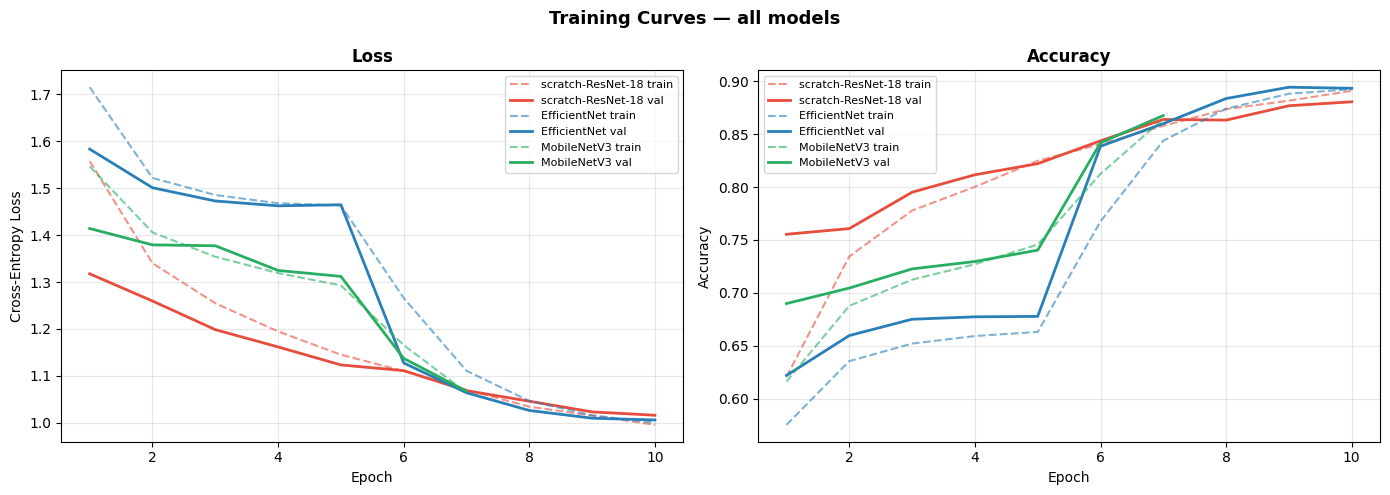

In [24]:
# ── Training Curves ──────────────────────────────────────────────────────────
hists  = [hist_resnet,  hist_eff,  hist_mob]
labels = ["scratch-ResNet-18", "EfficientNet", "MobileNetV3"]
colors = ["#e74c3c", "#2980b9", "#27ae60"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, lbl, col in zip(hists, labels, colors):
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], color=col, linestyle="--", alpha=0.6, label=f"{lbl} train")
    axes[0].plot(epochs, hist["val_loss"],   color=col, linestyle="-",  linewidth=2,  label=f"{lbl} val")
    axes[1].plot(epochs, hist["train_acc"],  color=col, linestyle="--", alpha=0.6, label=f"{lbl} train")
    axes[1].plot(epochs, hist["val_acc"],    color=col, linestyle="-",  linewidth=2,  label=f"{lbl} val")

axes[0].set_title("Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_title("Accuracy", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle("Training Curves — all models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Task 3, 4

In [27]:
@torch.no_grad()
def collect_predictions(model, loader, device=DEVICE):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1).cpu()
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
        all_probs.append(probs)
    return (
        torch.cat(all_preds).numpy(),
        torch.cat(all_labels).numpy(),
        torch.cat(all_probs).numpy(),
    )


def compute_all_metrics(model, loader, model_name, device=DEVICE):
    preds, labels, probs = collect_predictions(model, loader, device)
    f1_macro = f1_score(labels, preds, average="macro", zero_division=0)
    f1_per_class = f1_score(labels, preds, average=None, zero_division=0)
    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    cm = confusion_matrix(labels, preds)
    return dict(
        name=model_name,
        preds=preds,
        labels=labels,
        probs=probs,
        f1_macro=f1_macro,
        f1_per_class=f1_per_class,
        precision=precision,
        recall=recall,
        cm=cm,
    )


results_resnet  = compute_all_metrics(model_resnet,  test_loader, "Custom ResNet-18 (scratch)")
results_eff     = compute_all_metrics(model_eff,     test_loader, "EfficientNet-B0  (ImageNet → fine-tune)")
results_mob     = compute_all_metrics(model_mob,     test_loader, "MobileNetV3-Large (ImageNet → fine-tune)")

all_results = [results_resnet, results_eff, results_mob]

In [28]:
from IPython.display import HTML, display

def _f1_cell_color(v: float) -> str:
    if v >= 0.80:   return "#c6efce", "#276221"
    if v >= 0.50:   return "#ffeb9c", "#9c6500"
    return "#ffc7ce", "#9c0006"

def render_metrics_html(all_results, classes):
    header_cols = ["Model", "F1-macro", "Precision", "Recall"] + classes
    thead = "".join(f"<th>{c}</th>" for c in header_cols)

    rows_html = ""
    for res in all_results:
        bg, fg = _f1_cell_color(res["f1_macro"])
        row = f"""
        <tr>
          <td>{res['name']}</td>
          <td style="background:{bg};color:{fg}">{res['f1_macro']:.3f}</td>
          <td>{res['precision']:.3f}</td>
          <td>{res['recall']:.3f}</td>
        """
        for f1v in res["f1_per_class"]:
            b, f = _f1_cell_color(f1v)
            row += f'<td style="background:{b};color:{f}">{f1v:.3f}</td>'
        row += "</tr>"
        rows_html += row

    html = f"""
    <div style="overflow-x:auto">
      <table class="metrics-table">
        <thead><tr>{thead}</tr></thead>
        <tbody>{rows_html}</tbody>
      </table>
    </div>
    """
    display(HTML(html))

render_metrics_html(all_results, classes)

Model,F1-macro,Precision,Recall,Black,Grey,White,Blue,Silver,Red,Brown,Green,Yellow
Custom ResNet-18 (scratch),0.861,0.852,0.875,0.854,0.784,0.941,0.876,0.862,0.986,0.730,0.751,0.970
EfficientNet-B0 (ImageNet → fine-tune),0.874,0.859,0.896,0.878,0.799,0.942,0.900,0.881,0.987,0.738,0.773,0.965
MobileNetV3-Large (ImageNet → fine-tune),0.840,0.826,0.863,0.827,0.733,0.926,0.864,0.853,0.985,0.691,0.722,0.960


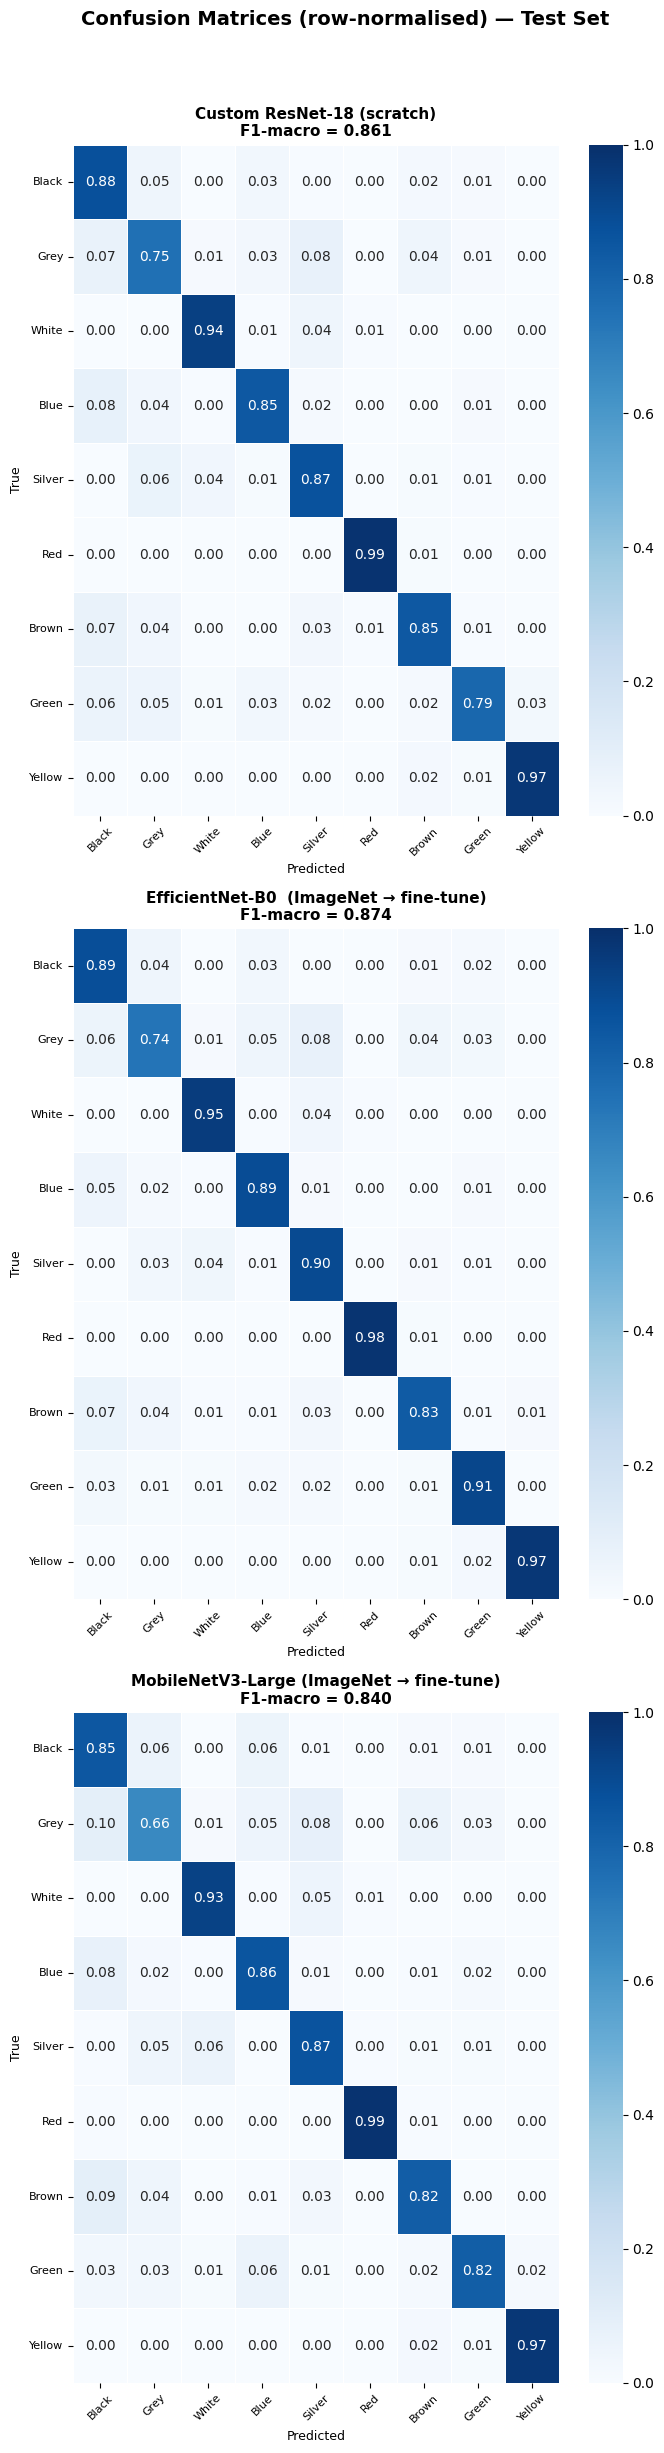

In [30]:
import seaborn as sns

# ── Confusion Matrices ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(7, 24))

for ax, res in zip(axes, all_results):
    cm_norm = res["cm"].astype(float) / res["cm"].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        linewidths=0.5,
        ax=ax,
        vmin=0,
        vmax=1,
    )
    ax.set_title(f"{res['name']}\nF1-macro = {res['f1_macro']:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.suptitle("Confusion Matrices (row-normalised) — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Image / True class,ResNet-18 (scratch),EfficientNet-B0,MobileNetV3-Large
True: Grey,✗ Silver 63.2%,✗ Silver 56.5%,✗ Green 37.1%
True: Grey,✗ Black 49.8%,✗ Black 51.0%,✗ Black 42.8%
True: Blue,✗ Black 45.6%,✗ Black 77.7%,✗ Black 80.9%
True: Grey,✗ Blue 36.0%,✗ Blue 40.3%,✗ Blue 40.2%
True: Black,✗ Grey 35.8%,✗ Grey 27.6%,✗ Grey 30.0%
True: Grey,✗ Brown 71.0%,✗ Brown 42.8%,✗ Brown 36.5%

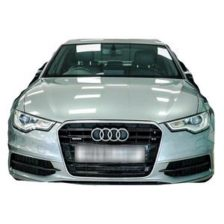
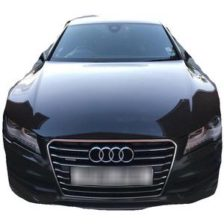
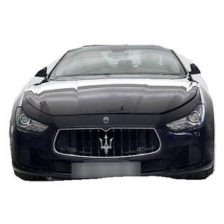
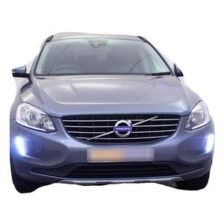
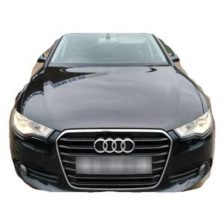
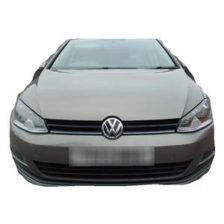

In [31]:
# ── Confused-Pair Gallery: how each model handles the hardest confusions ─────
import base64
from io import BytesIO

def _img_to_b64(img_tensor: torch.Tensor) -> str:
    denorm = (img_tensor * std + mean).clamp(0, 1)
    pil = Image.fromarray((denorm.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
    buf = BytesIO()
    pil.save(buf, format="JPEG", quality=82)
    return base64.b64encode(buf.getvalue()).decode()

@torch.no_grad()
def _predict(model, img_tensor, device=DEVICE):
    logits = model(img_tensor.unsqueeze(0).to(device))
    probs  = torch.softmax(logits, dim=1).cpu().squeeze()
    pred   = int(probs.argmax())
    return pred, float(probs[pred]) * 100


def render_confused_pairs_gallery(
    all_results,
    models_dict,      # {name: model}
    dataset,
    idx_to_class,
    device=DEVICE,
    n_pairs: int = 5,
    seed: int = 42,
):
    best_res = max(all_results, key=lambda r: r["f1_macro"])
    cm       = best_res["cm"].copy().astype(float)
    np.fill_diagonal(cm, 0)                      # zero diagonal (correct preds)

    flat    = cm.flatten()
    top_idx = flat.argsort()[::-1][:n_pairs]
    pairs   = [(int(i // len(idx_to_class)), int(i % len(idx_to_class))) for i in top_idx]

    rng = np.random.default_rng(seed)
    model_entries = list(models_dict.items())   # [(name, model), ...]
    header_cols   = "".join(
        f'<th>{n}</th>'
        for n, _ in model_entries
    )

    sections_html = ""
    for true_cls, pred_cls in pairs:
        cand = np.where(
            (best_res["labels"] == true_cls) & (best_res["preds"] == pred_cls)
        )[0]
        if len(cand) == 0:
            continue

        ds_idx = int(rng.choice(cand))
        img_tensor, _ = dataset[ds_idx]
        b64 = _img_to_b64(img_tensor)

        cells_html = ""
        for mname, mdl in model_entries:
            pred_lbl, conf = _predict(mdl, img_tensor, device)
            correct   = pred_lbl == true_cls
            badge_bg  = "#27ae60" if correct else "#e74c3c"
            badge_txt = "✓" if correct else "✗"
            cells_html += f"""
            <td style="text-align:center;padding:6px;border:1px solid #eee;vertical-align:top">
              <span style="background:{badge_bg};color:#fff">{badge_txt} {idx_to_class[pred_lbl]}</span><br>
              <span>{conf:.1f}%</span>
            </td>"""

        sections_html += f"""
        <tr>
          <td style="text-align:center;padding:4px;border:1px solid #eee">
            <img src="data:image/jpeg;base64,{b64}"/>
            <div>
              True: <b>{idx_to_class[true_cls]}</b>
            </div>
          </td>
          {cells_html}
        </tr>"""

    display(HTML(f"""
    <p style="font-family:sans-serif;font-size:12px;color:#555">
      Each row = one test image that the <b>best model</b> misclassified.
      Columns show what each model predicted.
    </p>
    <table>
      <thead><tr>
        <th>Image / True class</th>
        {header_cols}
      </tr></thead>
      <tbody>{sections_html}</tbody>
    </table>
    """))


models_dict = {
    "ResNet-18\n(scratch)":     model_resnet,
    "EfficientNet-B0":          model_eff,
    "MobileNetV3-Large":        model_mob,
}
render_confused_pairs_gallery(
    all_results, models_dict, test_dataset, idx_to_class,
    device=DEVICE, n_pairs=6, seed=42,
)

In [33]:

# ── Model Efficiency Table (params + inference time) ─────────────────────────
import time

def measure_inference_ms(model, device=DEVICE, n_runs: int = 100) -> float:
    """Average per-image inference time in milliseconds."""
    model.eval()
    dummy = torch.randn(1, 3, 224, 224, device=device)
    with torch.no_grad():
        for _ in range(10):                 # warm-up
            model(dummy)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs):
            model(dummy)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_runs * 1000


model_configs = [
    ("Custom ResNet-18 (scratch)",               model_resnet, results_resnet),
    ("EfficientNet-B0  (ImageNet -> fine-tune)",  model_eff,    results_eff),
    ("MobileNetV3-Large (ImageNet -> fine-tune)", model_mob,    results_mob),
]

rows_html = ""
for mname, mdl, res in model_configs:
    params  = sum(p.numel() for p in mdl.parameters()) / 1e6
    inf_ms  = measure_inference_ms(mdl, device=DEVICE)
    rows_html += f"""
    <tr>
      <td style="font-weight:600;white-space:nowrap;text-align:left">{mname}</td>
      <td>{params:.1f} M</td>
      <td>{inf_ms:.2f} ms</td>
    </tr>"""

display(HTML(f"""
<table class="eff-table">
  <thead><tr>
    <th>Model</th><th>Parameters</th><th>Inference / image</th>
  </tr></thead>
  <tbody>{rows_html}</tbody>
</table>
"""))


Model,Parameters,Inference / image
Custom ResNet-18 (scratch),11.2 M,5.41 ms
EfficientNet-B0 (ImageNet -> fine-tune),4.0 M,20.48 ms
MobileNetV3-Large (ImageNet -> fine-tune),4.2 M,23.69 ms
